# Notebook 1 — Fit linéaire avec incertitudes

Objectif : comprendre comment ajuster une droite à des données bruitées.

Modèle :

\[
y = mx + b
\]

où :

- \(x_i\) sont les valeurs contrôlées ;
- \(y_i\) sont les observations ;
- \(sigma_i\) sont les incertitudes sur les observations ;
- \(m\) et \(b\) sont les paramètres à estimer.

## Warm-up: simulated linear data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(seed=42)

m_true = 2.5
b_true = 1.0

x = np.linspace(0, 10, 20)
sigma_y = 1.0 * np.ones_like(x)

y_true = m_true * x + b_true
y_obs = y_true + rng.normal(0, sigma_y)

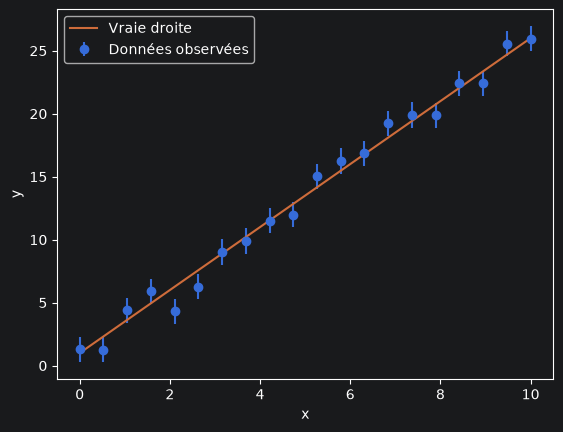

In [3]:
plt.errorbar(x, y_obs, yerr=sigma_y, fmt="o", label="Données observées")
plt.plot(x, y_true, label="Vraie droite")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Exercice 1 of 01_Hogg
Exercise 1: Using the standard linear algebra method of this Section, fit the straight line y = mx + b to the x, y, and σy values for data points 5 through 20 in Table 1 on page 6. That is, ignore the first four data points, and also ignore the columns for σx and ρxy. Make a plot showing the points, their uncertainties, and the best-fit line. Your plot should end up looking like Figure 1. What is the standard uncertainty variance σ2 m on the slope of the line?

In [4]:
ID = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
               11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

x = np.array([201, 244, 47, 287, 203, 58, 210, 202, 198, 158,
              165, 201, 157, 131, 166, 160, 186, 125, 218, 146])

y = np.array([592, 401, 583, 402, 495, 173, 479, 504, 510, 416,
              393, 442, 317, 311, 400, 337, 423, 334, 533, 344])

sigma_y = np.array([61, 25, 38, 15, 21, 15, 27, 14, 30, 16,
                    14, 25, 52, 16, 34, 31, 42, 26, 16, 22])

sigma_x = np.array([9, 4, 11, 7, 5, 9, 4, 4, 11, 7,
                    5, 5, 5, 6, 6, 5, 9, 8, 6, 5])

rho_xy = np.array([-0.84, 0.31, 0.64, -0.27, -0.33,
                   0.67, -0.02, -0.05, -0.84, -0.69,
                   0.30, -0.46, -0.03, 0.50, 0.73,
                   -0.52, 0.90, 0.40, -0.78, -0.56])

In [5]:
mask = ID >= 5

x_fit = x[mask]
y_fit = y[mask]
sigma_y_fit = sigma_y[mask]

In [6]:
u = np.ones_like(x_fit)
A = np.column_stack((u, x_fit))
C = np.diag(sigma_y_fit ** 2)
BM = np.linalg.inv(A.T @ np.linalg.inv(C) @ A) @ (A.T @ np.linalg.inv(C) @ y_fit)
print(BM)
b = BM[0]
m = BM[1]

[34.04772776  2.23992083]


In [7]:
print("Y shape:", y_fit.shape)
print("A shape:", A.shape)
print("C shape:", C.shape)
print("theta shape:", BM.shape)

Y shape: (16,)
A shape: (16, 2)
C shape: (16, 16)
theta shape: (2,)


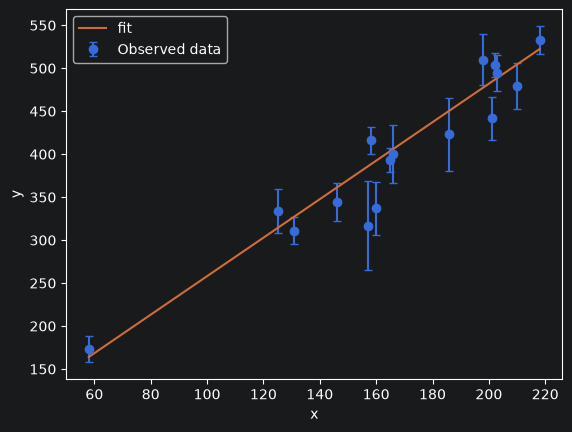

In [8]:
plt.figure()
plt.errorbar(x_fit, y_fit, yerr=sigma_y_fit, fmt="o",label="Observed data",capsize=3)
x_line = np.linspace(min(x_fit), max(x_fit), 100)
y_line = m * x_line + b
plt.plot(x_line,y_line, label="fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

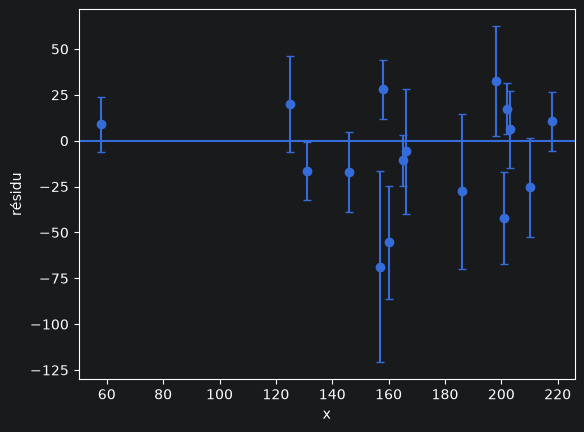

In [9]:
y_model = m * x_fit + b
residuals = y_fit - y_model
plt.figure()
plt.errorbar(x_fit, residuals, yerr=sigma_y_fit, fmt="o", capsize=3)
plt.axhline(0)
plt.xlabel("x")
plt.ylabel("résidu")
plt.show()

In [10]:
chi2 = np.sum((residuals / sigma_y_fit)**2)
dof = len(x_fit) - 2    #2 for b and m
chi2_reduced = chi2 / dof   #we divide by the nb of degrees of freedom

print(chi2)
print(chi2_reduced)

18.68076991124081
1.334340707945772


In [11]:
cov_theta = np.linalg.inv(A.T @ np.linalg.inv(C) @ A)   #matrix of uncertainties of the parameters
print(cov_theta)

sigma_b = np.sqrt(cov_theta[0, 0])
sigma_m = np.sqrt(cov_theta[1, 1])

print(b, "+-", sigma_b)
print(m, "+-", sigma_m)

[[ 3.32922601e+02 -1.88954491e+00]
 [-1.88954491e+00  1.16166311e-02]]
34.04772775754255 +- 18.246166749268173
2.2399208316310975 +- 0.10778047654050076


In [12]:
sigma_m_squared = cov_theta[1, 1]
print("Variance on the slope:", sigma_m_squared)

Variance on the slope: 0.011616631123297434


### Interpretation of the linear fit

In this exercise, the model is

$$
y = mx + b.
$$

The design matrix $A$ transforms the parameter vector

$$
\theta =
\begin{pmatrix}
b \\
m
\end{pmatrix}
$$

into the vector of model predictions $A\theta$.

The residual vector is

$$
r = Y - A\theta,
$$

which compares the observed data $Y$ to the model predictions.

The chi-squared statistic is

$$
\chi^2 = r^T C^{-1} r,
$$

or, for independent errors,

$$
\chi^2 = \sum_i \frac{r_i^2}{\sigma_i^2}.
$$

It measures how large the residuals are compared to the observational uncertainties.

Finally, the parameter covariance matrix is

$$
\mathrm{Cov}(\theta) = (A^T C^{-1} A)^{-1}.
$$

Its diagonal terms give the variances of the fitted parameters:

$$
\sigma_b = \sqrt{\mathrm{Cov}(\theta)_{00}},
\qquad
\sigma_m = \sqrt{\mathrm{Cov}(\theta)_{11}}.
$$

## Conclusion

In this notebook, we fitted a linear model y = m x + b to data with Gaussian uncertainties on y.

The residuals measure the difference between the observed data and the model prediction.

The chi-square quantifies the mismatch between the model and the data in units of the observational uncertainties.

The reduced chi-square is approximately 1.33. This is reasonably close to one and does
not reveal an obvious inconsistency between the linear model and the
quoted uncertainties, although it does not by itself prove that the model is correct.

The best-fit parameters are b = 34.05 +- 18.25 and m = 2.24 +- 0.11

The covariance matrix describes the uncertainty on the fitted parameters and their possible correlation.

A reduced chi-square close to 1 would indicate that the model is compatible with the data uncertainties.